In [47]:
# Initialize Otter
import otter
grader = otter.Notebook("hw1-task2.ipynb")

In [48]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Homework 1 Task 2: Simple Linear Regression 
## Do eDNA and Traditional Sampling Detect the Same Number of Fish Species?


---

### Background

Environmental DNA (eDNA) sampling detects species by collecting and sequencing genetic material shed into the water — no nets or electrofishing required. Traditional methods require direct capture or observation. This dataset, the same as used in Task 1, compiles results from **68 freshwater lake surveys** across multiple published studies, comparing species detected by each method.

Your goal is to investigate whether **eDNA-based species richness** (`dna_richness`) can predict **traditional species richness** (`trad_richness`) — the number of species found by conventional gear. This is a question for conservation monitoring: if the two methods broadly agree, eDNA could replace expensive field surveys.

You will build and evaluate a simple linear regression model from scratch using NumPy, and then verify your results with `sklearn` and `statsmodels`.

---


The dataset has the following key columns:

| Column | Description |
|---|---|
| `author` | First author of the primary study |
| `area_ha` | Lake area (hectares) |
| `dna_richness` | Number of fish species detected by eDNA |
| `trad_richness` | Number of fish species detected by conventional surveys |
| `dna_only` | Number of species found **only** by eDNA |
| `trad_only` | Number of species found **only** by conventional surveys |
| `shared` | Number of species found by **both** methods |
| `union` | Total unique species (`dna_only + trad_only + shared`) |
| `marker_cat` | Whether single or multiple genetic markers were used (single vs. multiple eDNA markers) |
| `gear_cat` | Whether single or multiple conventional survey gear types were used (single vs. multiple) |
| `total_vol_liter` | Total volume of water sampled (litres) |

### Setup: Load libraries and read in data


In [49]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Read in data 
df = pd.read_csv('lakes_data.csv') 
df.head()

,author,year_pub,area_ha,dna_richness,trad_richness,dna_only,trad_only,shared,union,marker_count,locus,marker_cat,gear_cat,match_effort,field_reps,rep_vol_liter,total_vol_liter
0,Civade,2016,545.0,14,18,1,5,13,19,1,12s,single,single,yes,3,45.00,135.00
1,Doble,2020,3290000.0,92,62,41,11,51,103,4,12s_16s,multiple,single,yes,21,10.00,210.00
2,Evans,2017,2.0,15,10,5,0,10,15,3,12s_16s_cytb,multiple,multiple,yes,31,0.25,7.75
3,Fujii,2019,9.0,0,7,0,7,0,7,1,12s,single,multiple,no,1,1.00,1.00
4,Fujii,2019,5.0,2,8,0,6,2,8,1,12s,single,multiple,no,1,1.00,1.00


<!-- BEGIN QUESTION -->

---
## Step 1: Visualise the Relationship

Create an exploratory data visualization exploring the relationship between `dna_richness` and `trad_richness`. 

<Axes: title={'center': 'DNA Richness vs Trad Richness'}, xlabel='DNA Richness', ylabel='Trad Richness'>

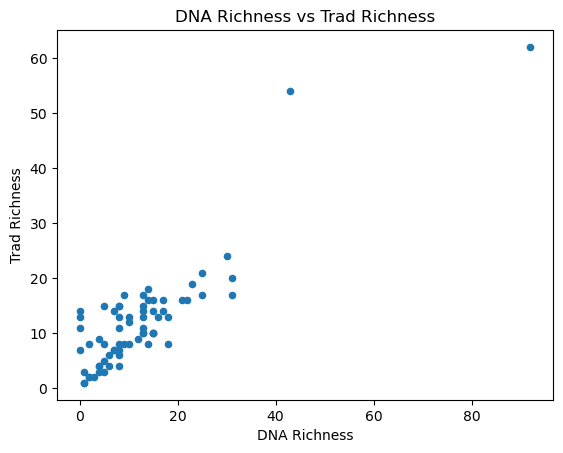

In [50]:
# Create a scatter plot of the 2 columns 
df.plot(kind = 'scatter', x = 'dna_richness', y = 'trad_richness', 
        title = "DNA Richness vs Trad Richness", 
        xlabel= "DNA Richness", 
        ylabel="Trad Richness")

> **Q1:** Does there appear to be a relationship between the two variables? Describe the direction, form, and approximate strength.

Increases in eDNA-based species richness has increasing traditional species richness. Therefore, there seems to be a positive relationship. 

<!-- END QUESTION -->

---
## Step 2: Fit the Regression 

Use `numpy` and the formula below to manually calculate β₁ and β₀. Store your coefficients in the `beta_1` and `beta_0` variables. Then, create a scatter plot of `trad_richness` and `dna_richness` (likely similar to the plot you created above!). Add the fitted line to the scatter plot, and the equation of the line as a legend item. 

$$\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

In [51]:
# Find the slope (B1)
beta_1 = ((df['dna_richness'] - df['dna_richness'].mean()) * (df['trad_richness'] - df['trad_richness'].mean())).sum() / ((df['dna_richness'] - (df['dna_richness'].mean()))**2).sum()

# Find y intercept (B0)
beta_0 = df['trad_richness'].mean() - (beta_1 * df['dna_richness'].mean())

# Print Statements 
print(f"\u03b2\u2081     = {beta_1:.4f}")
print(f"\u03b2\u2080     = {beta_0:.4f}")


β₁     = 0.6519
β₀     = 4.0013


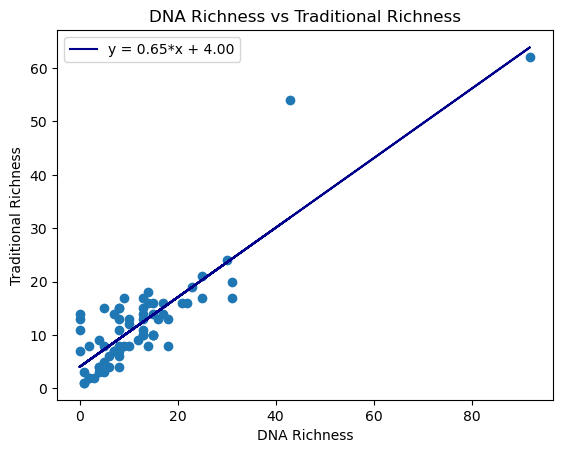

In [52]:
# Create a scatter plot with regression line 
# Empty Plot 
fig, ax = plt.subplots()

# Add scatter plot 
ax.scatter(df['dna_richness'], df['trad_richness'])

# Add regression line
ax.plot(df['dna_richness'], 
         beta_1 * df['dna_richness'] + beta_0, # Adding the regression line 
         color = 'darkblue', 
         label = f"y = {beta_1:.2f}*x + {beta_0:.2f}") # Equation in the line 

# Legend, title, and x&y labels 
ax.legend()
ax.set_title("DNA Richness vs Traditional Richness")
ax.set_xlabel("DNA Richness")
ax.set_ylabel("Traditional Richness")

plt.show()


In [53]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

---
## Step 3: Interpret the Coefficients



> **Q2:** Interpret the slope in plain language. Include units.





> **Q3:** Interpret the intercept. Is it ecologically meaningful?



With every 1 additional species seen within the eDNA methods, traditional species richness increases by 0.6516 species on average. 

When eDNA-based species richness is 0, traditional methods detects about 4 species. The y-intercept is not neccessarly ecologically meaningful. It just refers to the baseline species richness with only conventional gear and no eDNA methods.

<!-- END QUESTION -->

---
## Step 4: Compute Standard Errors

Use `numpy` and the formula below to manually calculate the standard errors. Store the RSE in a variable called `RSE`, the standard error of β₁ in a variable called `SE_beta_1`, and the standard error of β₀ in a variable called `SE_beta_0`. 

$$SS_{xx} = \sum(x_i - \bar{x})^2$$

$$RSE = \sqrt{\frac{RSS}{n-2}}$$

$$SE(\hat{\beta}_1) = \frac{RSE}{SS_{xx}}$$

$$SE(\hat{\beta}_0) = RSE \sqrt{\frac{1}{n} + \frac{\bar{x}^2}{SS_{xx}}}$$

In [54]:
# Solve for Sum of Squares 
SS = sum((df['dna_richness'] - df['dna_richness'].mean())**2) # = SUM(xi - xBAR)^2

# Solve for Yhat 
yhat = beta_0 + beta_1*df['dna_richness'] # = b0Hat + b1Hat * x

# Solve for Residuals Sum of Squares 
RSS = sum((df['trad_richness']-yhat)**2) # = SUM(yi - yHat)^2 = SUM(yi - B0Hat - B1Hat (x))^2 

# Solve for Relative Standard Error (RSE) 
RSE = (RSS/(df.shape[0] - 2))**.5 # = sqrt(RSS / (n-2))

# Solve for B1 Std Error 
SE_beta_1 = (RSE/((SS))**0.5) # = RSE / SS

# Solve for B0 Std Error 
SE_beta_0 = RSE * (((1/df.shape[0])+ (df['dna_richness'].mean()**2/SS))**.5)  #  = RSE (1/n + xHat^2 / SS)

# Print Statements 
print(f"RSE      = {RSE:.4f}  (species)")
print(f"SE(\u03b2\u2081)   = {SE_beta_1:.4f}")
print(f"SE(\u03b2\u2080)   = {SE_beta_0:.4f}")

RSE      = 4.7441  (species)
SE(β₁)   = 0.0446
SE(β₀)   = 0.7974


In [55]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 5: Manually Calculate 95% Confidence Intervals for $\beta_0$ and $\beta_1$

Using the formula below, manually calculate an approximate 95% confidence interval for β₀ and β₁. 

$$95\% \text{ CI} \simeq \hat{\beta}_i \pm 2 \times SE(\hat{\beta})$$

In [56]:
# Find the upper and low Confidence Intervals for beta 1 
CI_beta_1_lower = beta_1 - 2 * SE_beta_1
CI_beta_1_upper = beta_1 + 2 * SE_beta_1

# Find the upper and low Confidence Intervals for beta 0
CI_beta_0_lower = beta_0 - 2 * SE_beta_0
CI_beta_0_upper = beta_0 + 2 * SE_beta_0

# Print Statements
print(f"\n95% CI for \u03b2\u2081 (slope):  ({CI_beta_1_lower:.4f},  {CI_beta_1_upper:.4f})")
print(f"95% CI for \u03b2\u2080 (intercept): ({CI_beta_0_lower:.4f},  {CI_beta_0_upper:.4f})")


95% CI for β₁ (slope):  (0.5627,  0.7411)
95% CI for β₀ (intercept): (2.4064,  5.5962)


In [57]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Interpret the 95% CI for the slope in plain language.

95% confident that for every 1 species increase in DNA-base species richness, traditaionls species richness increases between 0.5627 and 0.7411 species on average.

95% confident that when DNA-base species richness is 0, traditaionls species richness is between 2.4064 and 5.5962 on average.

<!-- END QUESTION -->

---
## Step 6: Assess Model Accuracy — R²

Manually calculate the R² using the formula below. Store your answer in the `R2` variable. 

$$R^2 = 1 - \frac{RSS}{TSS} \qquad TSS = \sum_{i=1}^{n}(y_i - \bar{y})^2$$

In [58]:
TSS = ((df['trad_richness'] - df['trad_richness'].mean()) ** 2).sum()
R2     = 1 - (RSS / TSS)

print(f"R\u00b2     = {R2:.4f}")

R²     = 0.7640


In [59]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Interpret the R² in the context of this problem.

 76.40% of traditional species richness can be explained by the model/eDNA-based species richness. 

<!-- END QUESTION -->

---
## Step 7: Verify with `sklearn`

Let's confirm our manual OLS results using `sklearn`'s `LinearRegression`.

> **Note:** `sklearn` expects a 2D feature matrix, so we need to reshape `X` from
> shape `(n,)` to `(n, 1)` using `.reshape(-1, 1)` before fitting.

1. **Fit the model** — `LinearRegression().fit(X_2d, Y)` finds the same OLS solution as
   our manual β₁ and β₀ formulas.
2. **Extract coefficients** — `.coef_[0]` is the slope, `.intercept_` is the intercept.
3. **Compute R²** — `r2_score(Y, y_pred)` uses the $R^2 = 1 - RSS/TSS$. formula, where `y_pred = your_fitted_model.predict(X_2d)`
   
4. Create a table that compares the manually calculated and `LinearRegression()` generated slope, intercept, and R². 

If your manual calculations are correct, all three values should match `sklearn`'s output
to at least four decimal places. Any discrepancy beyond floating-point rounding
indicates a bug in your manual formulas.

In [60]:

# Convert X into a 2D Matrix
X_2d = np.array(df['dna_richness']).reshape(-1, 1) 

# Find Linear Regression info: beta1, intercept, R^2
sk_slope     = LinearRegression().fit(X_2d, df['trad_richness']).coef_[0]
sk_intercept = LinearRegression().fit(X_2d, df['trad_richness']).intercept_
y_pred = LinearRegression().fit(X_2d, df['trad_richness']).predict(X_2d) # Predicted values 
sk_r2        = r2_score(df['trad_richness'], y_pred)

# Print Statements - Table of manually vs LinearRegession() info
print(f"sklearn  slope     = {sk_slope:.4f},  manual slope     = {beta_1:.4f}")
print(f"sklearn  intercept = {sk_intercept:.4f},  manual intercept = {beta_0:.4f}")
print(f"sklearn  R\u00b2        = {sk_r2:.4f},  manual R\u00b2        = {R2:.4f}")

sklearn  slope     = 0.6519,  manual slope     = 0.6519
sklearn  intercept = 4.0013,  manual intercept = 4.0013
sklearn  R²        = 0.7640,  manual R²        = 0.7640


In [61]:
grader.check("q9")

q9 results: All test cases passed!

---
## Step 8: Verify with `statsmodels` 

`sklearn` is optimized for **prediction**: it fits models efficiently and scores them, but it deliberately leaves out statistical inference (standard errors, p-values, confidence intervals).

`statsmodels` is designed for **inference**: it fits the same OLS model but reports the full regression table — coefficients, standard errors, t-statistics, p-values, and confidence intervals — matching what you'd see in a statistics textbook.


1. Import `statsmodels.api as sm`.
2. Add a constant (intercept) column to `X` using `sm.add_constant()`.
3. Fit the model with `sm.OLS(Y, X_sm).fit()` and call `.summary()` to display the full regression table.
4. Extract the slope, intercept, and R² from the fitted model and compare them to your numpy and sklearn results. Store the statsmodels slope in `sm_slope`, the intercept in `sm_intercept`, and R² in `sm_r2`.

If all three methods are correct, the coefficients and R² should match to at least four decimal places.

In [62]:
# Import library
import statsmodels.api as sm 

# Create a Fit Model 
X_sm = sm.add_constant(df['dna_richness'])   # Add constant column to X 
model_fit = sm.OLS(df['trad_richness'], X_sm).fit() # Fit the model 
model_fit.summary() # Look at the summary 

# Find intercept, slope, and R^2
sm_intercept = model_fit.params['const']
sm_slope     = model_fit.params['dna_richness']
sm_r2        = model_fit.rsquared


In [63]:
grader.check("q10")

q10 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Look at the **p-values** for the slope (`dna_richness`) and intercept (`const`) in the statsmodels summary.
>
> - What does the p-value for the **slope** tell you? Is the relationship between eDNA richness and traditional richness statistically significant? How do you know?


The pvalue for the slope is 0.000 which is less then the critical value of 0.05. The likelihood of these results happening to chance is 0.00%. Therefore, there is a signifiant relationship between DNA-base species richness and traditional species richness. 

<!-- END QUESTION -->



---

**Run the cell below to receive credit for all auto graded questions.**

In [64]:
grader.check_all()

q10 results: All test cases passed!

q2 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!